# **To check these notebooks, the first one is timeseries where i explored the maximum and i tried a lot of things and i put all my remarks and ideas and put hypothisis and try to answer them later the second one forecasting based on cnt is the one where i do the assignment without diving a lot.**

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

## **Exploring Data**

In [39]:
df = pd.read_csv('bike_sharing_per_day.csv')

In [40]:
df.shape

(731, 16)

In [41]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [43]:
df_to_use = df[['dteday', 'cnt']]

In [44]:
df_to_use['dteday'] = pd.to_datetime(df_to_use['dteday'])

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_24620\2731951805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use['dteday'] = pd.to_datetime(df_to_use['dteday'])


In [45]:
df_to_use.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   dteday  731 non-null    datetime64[ns]
 1   cnt     731 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 11.6 KB


In [46]:
df_to_use.isnull().sum()

dteday    0
cnt       0
dtype: int64

This dataset should be cleaned before using it because it will create problems later on.

In [47]:
df_to_use.dropna(inplace=True)

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_24620\1691188311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use.dropna(inplace=True)


In [48]:
df_to_use.shape

(731, 2)

In [49]:
df_to_use.duplicated().sum()

0

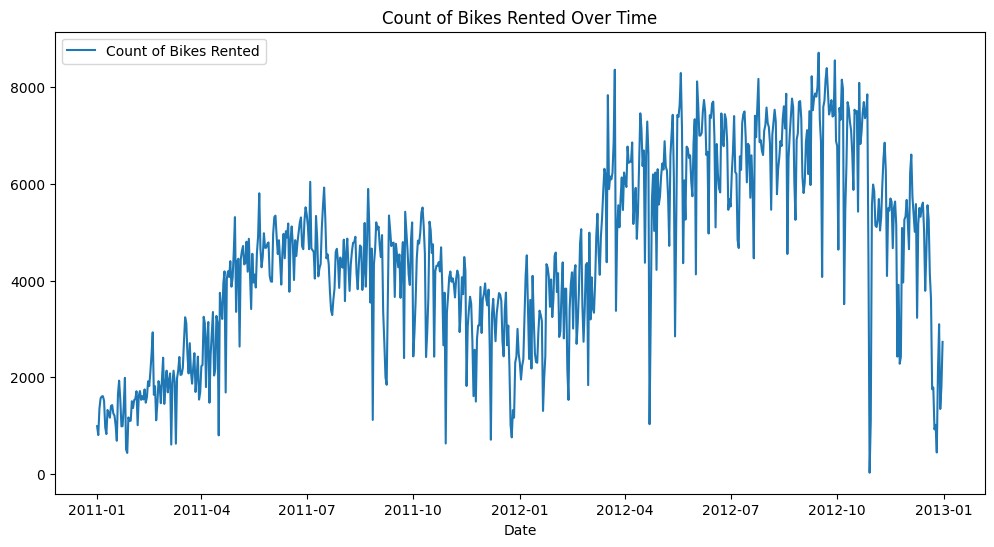

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(df_to_use['dteday'], df_to_use['cnt'], label='Count of Bikes Rented')
plt.xlabel('Date')
plt.title('Count of Bikes Rented Over Time')
plt.legend()
plt.show()

In [51]:
df_to_use.head()

,dteday,cnt
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600


# CNN Time Series

## **Data Manipulation**

In [52]:
value_column = 'cnt'
scaler = MinMaxScaler()
df_to_use[[value_column]] = scaler.fit_transform(df_to_use[[value_column]])
df_to_use.head()

C:\Users\Chourouk\AppData\Local\Temp\ipykernel_24620\1775145051.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_use[[value_column]] = scaler.fit_transform(df_to_use[[value_column]])


,dteday,cnt
0,2011-01-01,0.110792
1,2011-01-02,0.089623
2,2011-01-03,0.152669
3,2011-01-04,0.177174
4,2011-01-05,0.181546


This part is a correction for what happened later so i tried to change the value to make sure i don't have the same problem

In [53]:
print(df_to_use[df_to_use[value_column] == 0])

        dteday  cnt
667 2012-10-29  0.0


In [54]:
df_to_use.loc[662 : 672]

,dteday,cnt
662,2012-10-24,0.882536
663,2012-10-25,0.844110
664,2012-10-26,0.853889
665,2012-10-27,0.900828
666,2012-10-28,0.510469
667,2012-10-29,0.000000
668,2012-10-30,0.123562
669,2012-10-31,0.637828
670,2012-11-01,0.686148
671,2012-11-02,0.670156


In [55]:
# i chose to change the value to make sure i don't have the same problem
# so i set it to the mean of the previous and next value as a first approximation
df_to_use.loc[667, value_column] = (df_to_use.loc[666, value_column] + df_to_use.loc[668, value_column]) / 2
print(df_to_use[value_column].nsmallest(3))

26     0.047055
725    0.048205
25     0.055683
Name: cnt, dtype: float64


In [56]:
df_to_use = df_to_use.drop('dteday', axis=1)
df_to_use.index = df_to_use.index * 0.1 + 1

In [57]:
df_to_use.head()

,cnt
1.0,0.110792
1.1,0.089623
1.2,0.152669
1.3,0.177174
1.4,0.181546


## **Train/test -split**

In [58]:
cutoff = int(len(df_to_use) * 0.8)

# train data
X_train = df_to_use.index[0:cutoff]
y_train = df_to_use[value_column].iloc[0:cutoff]

# test data
X_test = df_to_use.index[cutoff:]
y_test = df_to_use[value_column].iloc[cutoff:]

# convert everything into NumPy -array format
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

# in this case, number of variables is 1 => scaled passengers value
n_features = 1

# use reshape tools to get the data ready for future use
train_series = y_train.reshape((len(y_train), n_features))
test_series  = y_test.reshape((len(y_test), n_features))


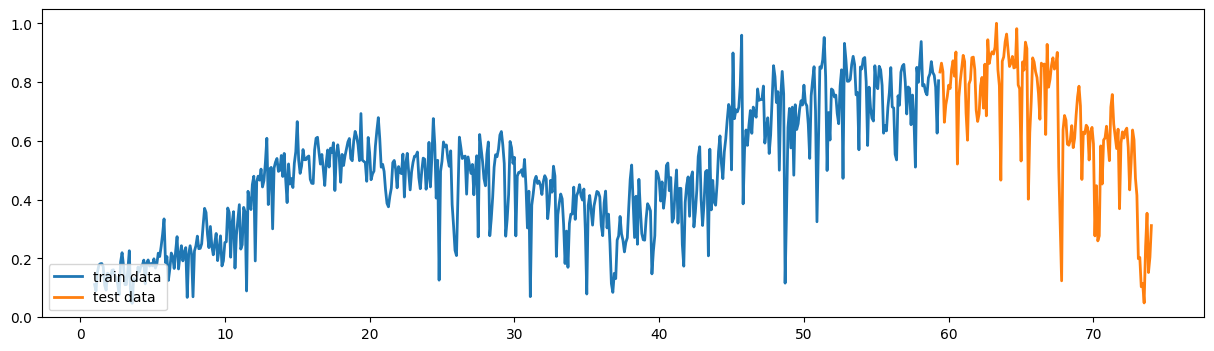

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))

# Plot ONLY the cnt values
ax.plot(X_train, y_train, lw=2, label='train data')
ax.plot(X_test,  y_test,  lw=2, label='test data')

ax.legend(loc="lower left")
plt.show()


In [60]:
from tensorflow.keras.utils import timeseries_dataset_from_array

look_back  = 4
batch_size = 1
window_size = 1


train_generator = timeseries_dataset_from_array(
    data=train_series,
    targets=train_series[look_back:],
    sequence_length=look_back,
    sampling_rate=1,
    sequence_stride=window_size,
    batch_size=batch_size,
    shuffle=False,
)

test_generator = timeseries_dataset_from_array(
    data=test_series,
    targets=test_series[look_back:],
    sequence_length=look_back,
    sampling_rate=1,
    sequence_stride=window_size,
    batch_size=batch_size,
    shuffle=False,
)

In [61]:
from keras.models import Sequential
from keras import Input
from keras.layers import LSTM
from keras.layers import Dense
from keras.callbacks import ModelCheckpoint, EarlyStopping

mc = ModelCheckpoint('best_model_forecasting_one.keras',
                     monitor='val_loss', mode='min', save_best_only=True)

es = EarlyStopping(monitor='val_loss',
                   patience=10,
                   restore_best_weights=True)


callback_list = [mc]

n_neurons  = 32

model = Sequential()
model.add(Input(shape=(look_back, n_features)))
model.add(LSTM(n_neurons, activation="relu"))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


model.fit(train_generator, 
          epochs=50, 
          verbose=1, 
          validation_data=test_generator, 
          callbacks=callback_list)


Epoch 1/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0113 - val_loss: 0.0267
Epoch 2/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0127 - val_loss: 0.0263
Epoch 3/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0126 - val_loss: 0.0259
Epoch 4/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0125 - val_loss: 0.0255
Epoch 5/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0124 - val_loss: 0.0251
Epoch 6/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0122 - val_loss: 0.0247
Epoch 7/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0121 - val_loss: 0.0243
Epoch 8/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0120 - val_loss: 0.0239
Epoch 9/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0119 - val_loss: 0.0236
Epoch 10/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0118 - val_loss: 0.0233
Epoch 11/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0117 - val_loss: 0.0230
Epoch 12/50
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

<Axes: >

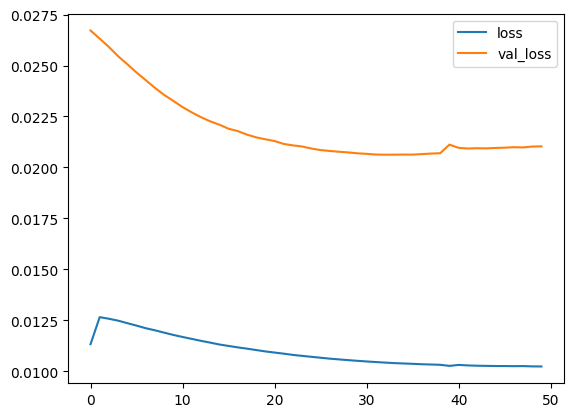

In [62]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [63]:
from keras.models import load_model
model = load_model("best_model_forecasting_one.keras")

In [64]:
# TensorFlow evaluation metrics
result = model.evaluate(train_generator)
print(f"Training loss: {result}")

# test loss
result = model.evaluate(test_generator)
print(f"Testing loss: {result}")

580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0201
Training loss: 0.020084964111447334
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0206  
Testing loss: 0.020626824349164963


In [65]:
test_predictions  = model.predict(test_generator)

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [66]:
actual_y_test = np.concatenate([y for x, y in test_generator])
mape = mean_absolute_percentage_error(actual_y_test, test_predictions) * 100

# print out the MAPE-score
print("MAPE (mean average precision error):")
print(f"{round(mape, 2)} %")

# MAE - Mean average error
print("\nMAE")
print(round(metrics.mean_absolute_error(actual_y_test, test_predictions), 2), "units")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(actual_y_test, test_predictions), 2), "units^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(actual_y_test, test_predictions)), 2), "units")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(actual_y_test, test_predictions), 2))

MAPE (mean average precision error):
28.79 %

MAE
0.1 units

MSE
0.02 units^2

RMSE:
0.14 units

R-squared:
0.54


The model is not a very good one as the ability to describe the dataset is midium

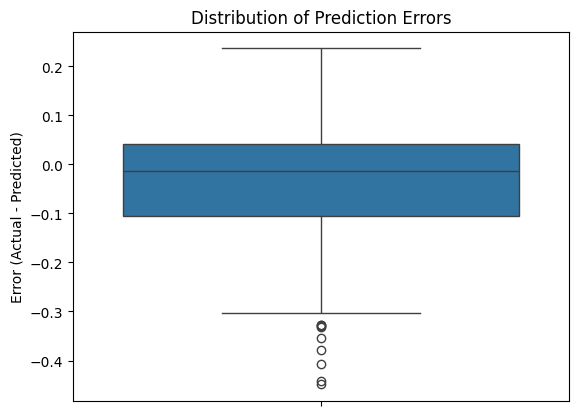

In [67]:
comparison = pd.DataFrame({
    "actual cnt": actual_y_test[:, 0].flatten(),
    "predicted cnt": test_predictions[:, 0].flatten(),
    "difference": actual_y_test[:, 0].flatten() - test_predictions[:, 0].flatten()
})
sns.boxplot(data=comparison, y='difference')
plt.title('Distribution of Prediction Errors')
plt.ylabel('Error (Actual - Predicted)')
plt.show()

According the boxplot the model usually predicts bigger values that the reality

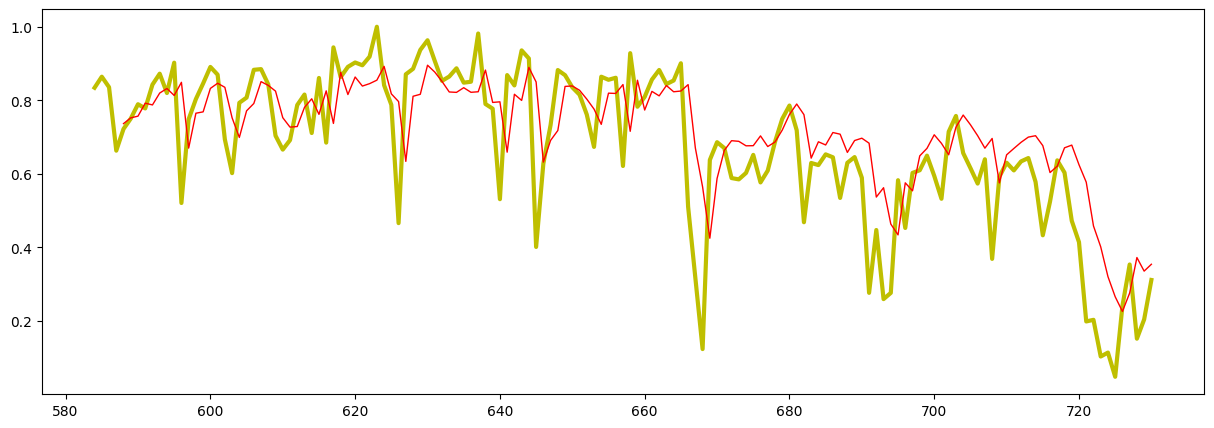

In [68]:
x1 = np.arange(0, len(y_train))
x2 = np.arange(len(y_train), len(y_train) + len(y_test))
x3 = np.arange(len(y_train) + look_back, len(y_train) + len(y_test))

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(x2, y_test, lw=3, c='y', label='test data')
ax.plot(x3, test_predictions, lw=1, c='r', label='predictions')
plt.show()

In [69]:
# TensorFlow evaluation metrics
result = model.evaluate(train_generator)
print(f"Training loss: {result}")

# test loss
result = model.evaluate(test_generator)
print(f"Testing loss: {result}")

580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0201
Training loss: 0.020084964111447334
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0206  
Testing loss: 0.020626824349164963


In [70]:
# EXTRAPOLATION TEST 1 - 180 new points
extrapolation = list()
seed_batch    = y_test[:look_back].reshape((1,look_back, n_features))
current_batch = seed_batch

# extrapolate the next 180 values
for i in range(120):
    predicted_value = model.predict(current_batch, verbose=None)[0]

    extrapolation.append(predicted_value) 
    
    current_batch = np.append(current_batch[:,1:,:],
                              [[predicted_value]],
                              axis=1)

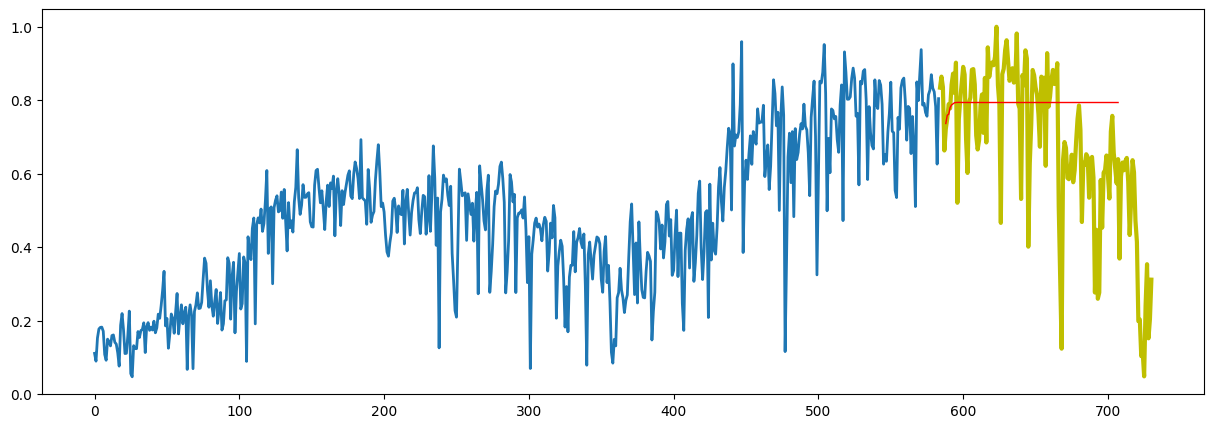

In [71]:
x1 = np.arange(0, len(y_train))
x2 = np.arange(len(y_train), len(y_train) + len(y_test))
x3 = np.arange(len(y_train) + look_back, len(y_train) + len(extrapolation) + look_back)

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
ax.plot(x1, y_train, lw=2, label='train data')
ax.plot(x2, y_test, lw=3, c='y', label='test data')
ax.plot(x3, extrapolation, lw=1, c='r', label='predictions')
plt.show()

In [72]:
df_extra = pd.DataFrame(data=extrapolation)

In [73]:
df_extra.describe()

,0
count,120.000000
mean,0.792594
std,0.006820
min,0.736656
25%,0.793817
50%,0.793817
75%,0.793817
max,0.794114


In [74]:
df_extra.var()

0    0.000047
dtype: float32